In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(5)

days = np.arange(1, 31)

# Умовно кожен 6-й і 7-й день тижня — вихідний
weekend = np.isin(days % 7, [6, 0])

# Температура: базова 2°C + випадкове відхилення приблизно ±3°C
temperature = np.round(
    2 + np.random.uniform(-3, 3, size=30), 1
)

# Базові продажі — 45 шт./день + випадкова варіація
sales = 45 + np.random.randint(-6, 7, size=30)

# У вихідні продажі вищі на 15–25%
weekend_increase = np.random.uniform(1.15, 1.25, size=30)
sales = np.where(weekend, sales * weekend_increase, sales)
sales = np.round(sales).astype(int)

df = pd.DataFrame({
    "день": days,
    "вихідний": weekend,
    "температура": temperature,
    "продажі": sales
})

print("Варіант 5 — Дніпро")
df

Варіант 5 — Дніпро


,день,вихідний,температура,продажі
0,1,False,0.3,48
1,2,False,4.2,42
2,3,False,0.2,42
3,4,False,4.5,41
4,5,False,1.9,40
5,6,True,2.7,52
6,7,True,3.6,57
7,8,False,2.1,43
8,9,False,0.8,51
9,10,False,0.1,50


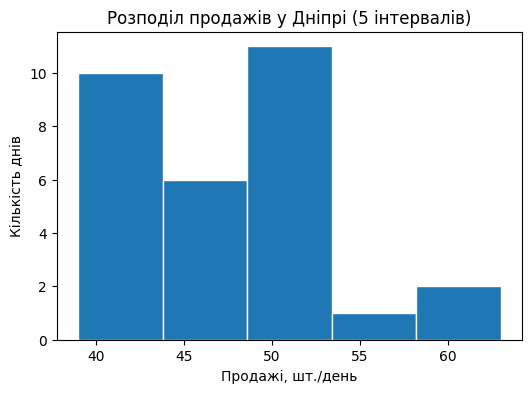

In [2]:
fig, ax = plt.subplots(figsize=(6, 4))

ax.hist(df["продажі"], bins=5, edgecolor="white")

ax.set_xlabel("Продажі, шт./день")
ax.set_ylabel("Кількість днів")
ax.set_title("Розподіл продажів у Дніпрі (5 інтервалів)")

plt.show()

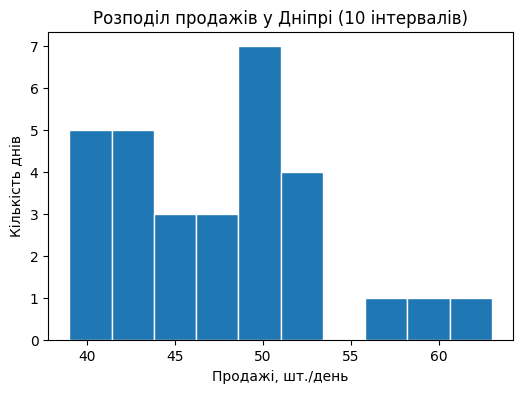

In [3]:
fig, ax = plt.subplots(figsize=(6, 4))

ax.hist(df["продажі"], bins=10, edgecolor="white")

ax.set_xlabel("Продажі, шт./день")
ax.set_ylabel("Кількість днів")
ax.set_title("Розподіл продажів у Дніпрі (10 інтервалів)")

plt.show()

Для набору з 30 значень гістограма з 5 інтервалами є більш
змістовною. Вона чіткіше показує загальну форму розподілу продажів.

При bins=10 дані поділяються на занадто багато вузьких інтервалів,
тому через невелику кількість спостережень гістограма виглядає
більш нерівномірною.

/tmp/ipykernel_1049/1256266979.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(


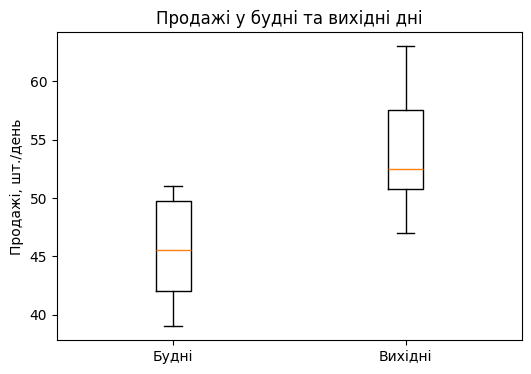

In [4]:
weekday_sales = df.loc[~df["вихідний"], "продажі"]
weekend_sales = df.loc[df["вихідний"], "продажі"]

fig, ax = plt.subplots(figsize=(6, 4))

ax.boxplot(
    [weekday_sales, weekend_sales],
    labels=["Будні", "Вихідні"]
)

ax.set_ylabel("Продажі, шт./день")
ax.set_title("Продажі у будні та вихідні дні")

plt.show()

На boxplot видно, що медіана продажів у вихідні вища, ніж у будні.

Це відповідає способу генерації даних у Завданні 1, оскільки
для вихідних днів продажі були штучно збільшені на 15–25%.

Розкид значень у двох групах також можна порівняти за розмірами
ящиків та довжиною їхніх "вусів".

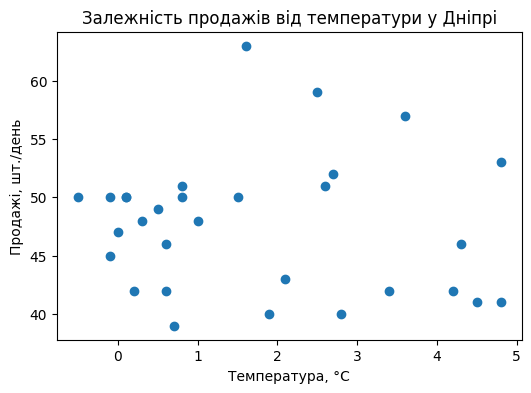

In [5]:
fig, ax = plt.subplots(figsize=(6, 4))

ax.scatter(df["температура"], df["продажі"])

ax.set_xlabel("Температура, °C")
ax.set_ylabel("Продажі, шт./день")
ax.set_title("Залежність продажів від температури у Дніпрі")

plt.show()

На діаграмі розсіювання не спостерігається чіткої залежності
між температурою та кількістю продажів.

Точки розташовані досить розсіяно, тому зі збільшенням температури
продажі не демонструють однозначного зростання або зменшення.

Це очікувано для створеного набору, оскільки під час генерації
даних продажі залежали переважно від випадкової варіації та
наявності вихідного дня, а не від температури.

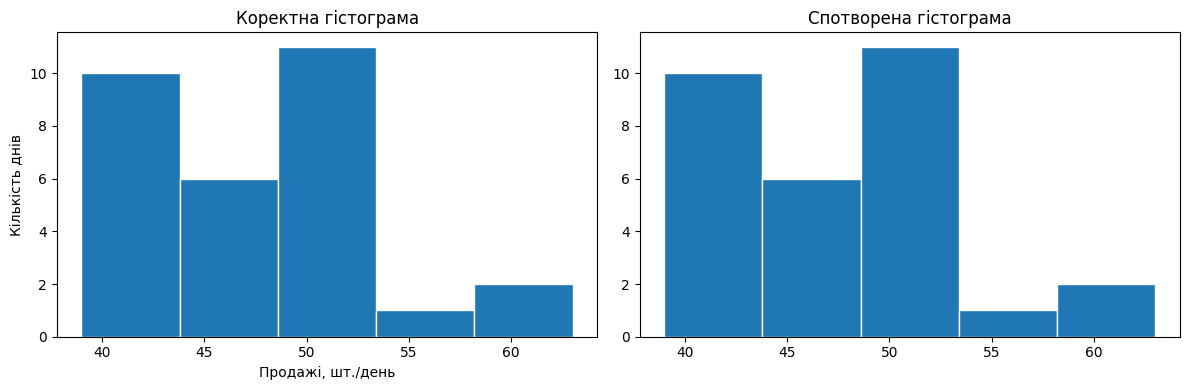

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Коректний графік
axes[0].hist(df["продажі"], bins=5, edgecolor="white")
axes[0].set_xlabel("Продажі, шт./день")
axes[0].set_ylabel("Кількість днів")
axes[0].set_title("Коректна гістограма")

# Спотворений графік
axes[1].hist(df["продажі"], bins=5, edgecolor="white")
axes[1].set_title("Спотворена гістограма")

plt.tight_layout()
plt.show()

На другому графіку навмисно прибрано підписи осей та одиниці
вимірювання.

Через це читач бачить форму графіка, але не може однозначно
визначити, що саме показано на осях та в яких одиницях вимірюються
значення.

Таке оформлення може призвести до неправильного трактування даних.
Коректний графік повинен містити зрозумілий заголовок, підписи осей
та одиниці вимірювання.

Контрольні питання

1. Чому обрізана вісь Y перебільшує різницю?

Якщо вісь Y починається не з нуля, невеликі відмінності між
значеннями візуально здаються значно більшими. Числа при цьому
можуть залишатися правильними, але масштаб графіка створює
спотворене враження про величину різниці.

2. Коли лінійний графік є методологічною помилкою?

Наприклад, неправильно з'єднувати лінією категорії "Київ",
"Дніпро", "Львів". Назви міст є номінальними категоріями і між
ними немає природної числової послідовності. Лінія створювала б
хибне враження безперервного переходу між категоріями.

3. Чому підписи осей, одиниці та заголовок важливі?

Вони пояснюють, які саме величини показані на графіку та в яких
одиницях вони вимірюються. Без них графік може бути неоднозначним
і його легко неправильно інтерпретувати.

4. Що таке chartjunk?

Chartjunk — це зайві декоративні елементи графіка, які не несуть
корисної інформації. Наприклад, непотрібні 3D-ефекти, надмірні
кольори або декоративні фігури. Вони відволікають від даних та
можуть ускладнювати або спотворювати їх сприйняття.